<a href="https://colab.research.google.com/github/HarshithaBoppudi/Harshitha_Boppudi_Module_5_Part2/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Computer vision problem the dataset represents is Image Classification
Reason: The dataset is only clasifying the images but does not include finding location or the pixel size or identify the instances individually. Each image belongs to one of four mutually exclusive classes (normal, scratch, dent, stain). There are no bounding boxes or pixel-level masks, so classification is the right formulation.

--- Dataset Analysis ---
Detected Classes: ['Scratch', 'dent', 'normal', 'stain']

--- Image Counts per Class ---
Scratch: 120 images
dent: 120 images
normal: 120 images
stain: 120 images

--- Sample Image Dimensions per Class ---
Scratch: (96, 96, 3)
dent: (96, 96, 3)
normal: (96, 96, 3)
stain: (96, 96, 3)

--- Sample Images per Class ---


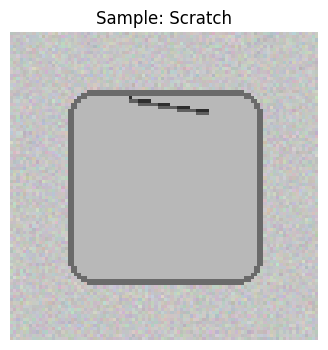

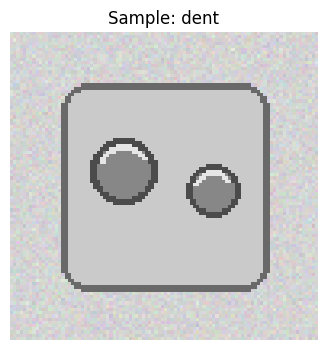

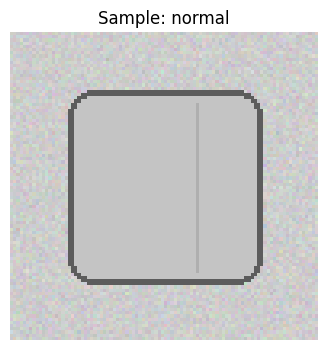

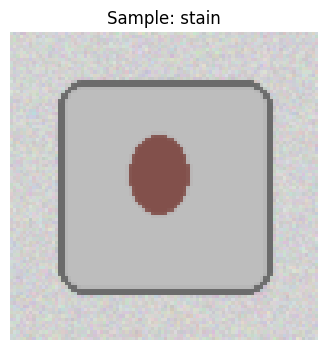


--- Dataset Imbalance ---
Scratch: 120 images (25.00%)
dent: 120 images (25.00%)
normal: 120 images (25.00%)
stain: 120 images (25.00%)


In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict

# Count images per class
data_dir = "/content/"
class_counts = defaultdict(int)
class_samples = {} # To store one sample image path per class
image_dimensions = {} # To store dimensions for each class
all_classes = set()


for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)


    if os.path.isdir(class_path) and class_name not in ['.config', '.ipynb_checkpoints', 'sample_data']:
        all_classes.add(class_name)
        image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        class_counts[class_name] = len(image_files_in_class)

        if image_files_in_class:
            # Store one sample image path
            sample_img_filename = image_files_in_class[0]
            class_samples[class_name] = os.path.join(class_path, sample_img_filename)

            # Get image dimensions from the first sample
            try:
                sample_img = mpimg.imread(class_samples[class_name])
                image_dimensions[class_name] = sample_img.shape
            except Exception as e:
                print(f"Could not read image {class_samples[class_name]} for dimensions: {e}")


# Convert set of classes to a list for consistent ordering
classes = sorted(list(all_classes))

print("--- Dataset Analysis ---")
print("Detected Classes:", classes)

print("\n--- Image Counts per Class ---")
for cls in classes:
    count = class_counts.get(cls, 0)
    print(f"{cls}: {count} images")

print("\n--- Sample Image Dimensions per Class ---")
for cls in classes:
    dims = image_dimensions.get(cls, "N/A")
    print(f"{cls}: {dims}")

print("\n--- Sample Images per Class ---")
# Show sample images
for cls in classes:
    if cls in class_samples:
        img_path = class_samples[cls]
        plt.figure(figsize=(4, 4)) # Set figure size for better display
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(f"Sample: {cls}")
        plt.axis('off')
        plt.show()

# Check for imbalance
total_images = sum(class_counts.values())
if total_images > 0:
    print("\n--- Dataset Imbalance ---")
    for cls in classes:
        count = class_counts.get(cls, 0)
        percentage = (count / total_images) * 100
        print(f"{cls}: {count} images ({percentage:.2f}%)")
else:
    print("\nNo images found to check for imbalance.")


**TASK 3**

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)  # resize all images

datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixels
    validation_split=0.2,    # split train/val
    rotation_range=20,       # augmentation
    horizontal_flip=True
)

# Store original parameters for re-creating generators
train_params = {
    'directory': data_dir, 'target_size': img_size, 'batch_size': 32,
    'class_mode': 'categorical', 'subset': 'training', 'classes': classes
}
val_params = {
    'directory': data_dir, 'target_size': img_size, 'batch_size': 32,
    'class_mode': 'categorical', 'subset': 'validation', 'classes': classes
}

# Create a sample generator just to get num_samples and num_classes for printing/steps_per_epoch
# This will be used only for metadata, not for actual data feeding to model.fit
_keras_train_gen = datagen.flow_from_directory(**train_params)
_keras_val_gen = datagen.flow_from_directory(**val_params)

# Define the output signature for the tf.data.Dataset
output_signature = (
    tf.TensorSpec(shape=(None, img_size[0], img_size[1], 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None, len(classes)), dtype=tf.float32)
)

# Callable for tf.data.Dataset.from_generator that returns a NEW iterator each time
def train_generator_fn():
    current_generator = datagen.flow_from_directory(**train_params)
    while True:
        for x, y in current_generator:
            yield x, y

def val_generator_fn():
    current_generator = datagen.flow_from_directory(**val_params)
    while True:
        for x, y in current_generator:
            yield x, y

# Convert to tf.data.Dataset
train_gen = tf.data.Dataset.from_generator(
    train_generator_fn,
    output_signature=output_signature
)

val_gen = tf.data.Dataset.from_generator(
    val_generator_fn,
    output_signature=output_signature
)

# Print statements for confirmation
print(f"Found {_keras_train_gen.samples} images belonging to {_keras_train_gen.num_classes} classes for training.")
print(f"Found {_keras_val_gen.samples} images belonging to {_keras_val_gen.num_classes} classes for validation.")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Found 384 images belonging to 4 classes for training.
Found 96 images belonging to 4 classes for validation.


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0],img_size[1],3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='softmax')  # output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,668 (6.20 MB)

 Trainable params: 1,625,668 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
Found 384 images belonging to 4 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.2277 - loss: 1.8105Found 96 images belonging to 4 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.2318 - loss: 1.6352 - val_accuracy: 0.2500 - val_loss: 1.3869
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.2179 - loss: 1.3883Found 96 images belonging to 4 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.2057 - loss: 1.3895 - val_accuracy: 0.2500 - val_loss: 1.3830
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.2208 - loss: 1.3845Found 96 images belonging to 4 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 460ms/step - accuracy: 0.2500 - loss: 1.3832 - val_accuracy: 0.2500 - val_loss: 1.3747
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.3465 - loss: 1.3720Found 96 images belonging to 4 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step - accuracy: 0.3724 - loss: 1.3649 - val_accuracy: 0.5000 - val_loss

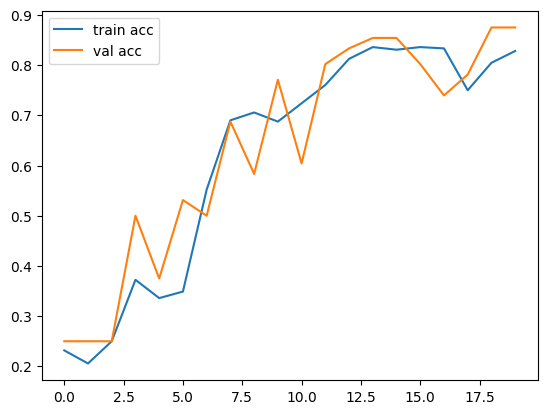

Found 96 images belonging to 4 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
[[ 5  5  8  6]
 [ 3  9  8  4]
 [ 3  9  6  6]
 [12  2  4  6]]


In [20]:
steps_per_epoch = _keras_train_gen.samples // _keras_train_gen.batch_size # Use _keras_train_gen to get sample count
validation_steps = _keras_val_gen.samples // _keras_val_gen.batch_size # Use _keras_val_gen to get sample count

history = model.fit(train_gen, epochs=20,
                    steps_per_epoch=steps_per_epoch,
                    validation_data=val_gen,
                    validation_steps=validation_steps)

# Plot accuracy/loss curves
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.show()

# Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix

# Get true labels from the original Keras generator
# This is crucial because val_gen is now a tf.data.Dataset and does not have .classes
y_true = _keras_val_gen.classes

# Predict using the validation dataset
# The number of steps for prediction should also be explicitly provided
y_pred = model.predict(val_gen, steps=validation_steps)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_true, y_pred_classes))

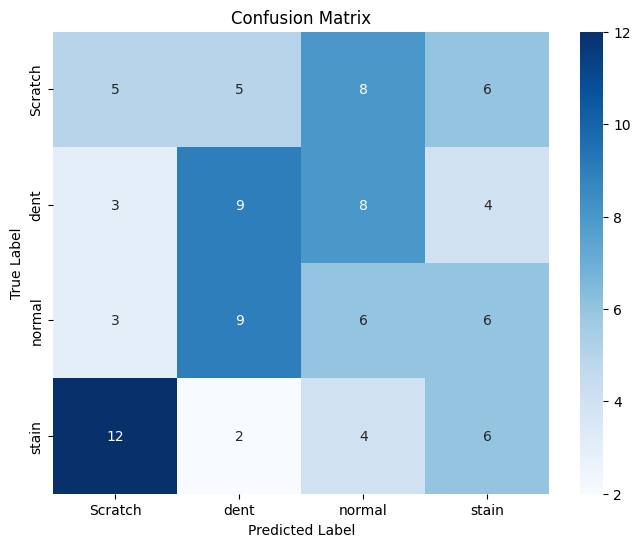

In [21]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Sample Predictions on Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


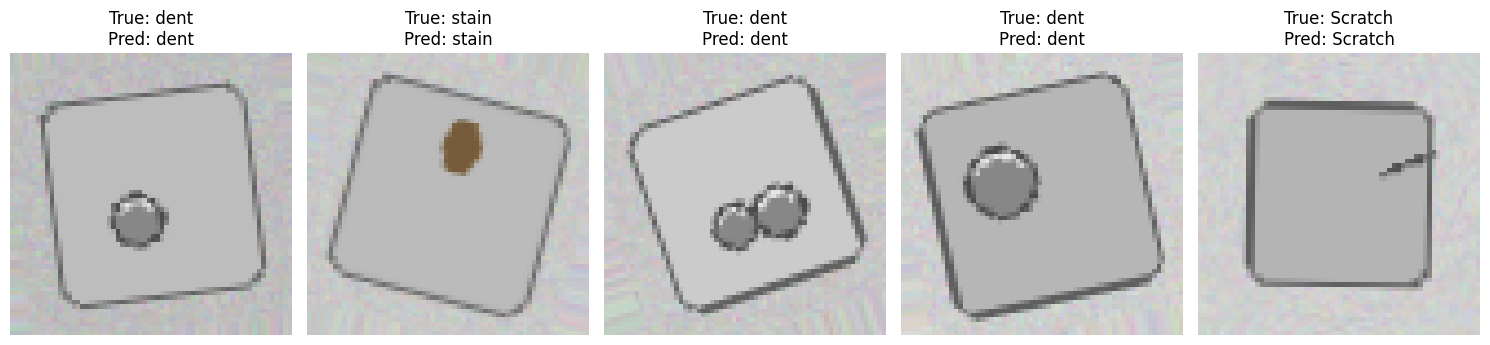

In [22]:

_keras_val_gen.reset()

num_samples_to_show = 5

images_batch, labels_batch = next(_keras_val_gen)

# Predict on these specific images
predictions = model.predict(images_batch)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels_batch, axis=1)

plt.figure(figsize=(15, 10))
for i in range(num_samples_to_show):
    plt.subplot(1, num_samples_to_show, i + 1)
    plt.imshow(images_batch[i])
    plt.title(f"True: {classes[true_classes[i]]}\nPred: {classes[predicted_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()